In [27]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [28]:
# =====================================================
# Load Train-Test Dataset (CSV)
# =====================================================



# Load feature matrices
X_train = pd.read_csv("/workspaces/pcf-quality-framework/BEACON-PCF/data/X_train.csv")
X_test = pd.read_csv("/workspaces/pcf-quality-framework/BEACON-PCF/data/X_test.csv")

# Load target variables
y_train = pd.read_csv("/workspaces/pcf-quality-framework/BEACON-PCF/data/y_train.csv").squeeze()
y_test = pd.read_csv("/workspaces/pcf-quality-framework/BEACON-PCF/data/y_test.csv").squeeze()

print("Train/Test Shapes")
print("-" * 30)
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)





Train/Test Shapes
------------------------------
X_train: (692, 34)
X_test : (174, 34)
y_train: (692,)
y_test : (174,)


In [29]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

In [30]:
from sklearn.preprocessing import StandardScaler

numeric_features = [
    "Company",
    "Product_Weight"
]

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Fit scaler ONLY on training data
X_train_scaled[numeric_features] = scaler.fit_transform(
    X_train[numeric_features]
)

# Apply the same scaler to test data
X_test_scaled[numeric_features] = scaler.transform(
    X_test[numeric_features]
)

StandardScaler is applied only to the continuous numerical features
(Company and Product_Weight) as value are not in range. Linear models are sensitive to feature
scale, whereas one-hot encoded binary features do not require scaling.



After one-hot encoding, you'll have around 60–80 features (depending on the categories).

Your dataset has 866 samples.

This is not a high-dimensional dataset. PCA is generally more useful when you have hundreds or thousands of correlated numerical features (e.g., images, gene expression data, text embeddings). With your structured tabular data, PCA may:

reduce interpretability,
mix one-hot encoded categorical features into principal components,
make it harder to explain the model in your dissertation,
and may not improve prediction performance.

Most tree-based models you're planning to use (Random Forest, XGBoost, CatBoost) do not benefit from PCA.

In [31]:

# Model Performance Table
# =====================================================

results = pd.DataFrame(
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "R2_Original",
        "R2_Log"
    ]
)

# Model 1 : Linear Regression

In [32]:

# Model 1 : Linear Regression
# =====================================================

from sklearn.linear_model import LinearRegression
from sklearn.metrics import PredictionErrorDisplay

In [33]:
# Initialize model
lr = LinearRegression()
lr.fit(
    X_train_scaled,
    y_train_log
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](34,)","[ 0.14, 0.02, 0. ,...,-0.07,-0.55, 2.38]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](34,)","['Year','Company','Stage_Level_CO2e_Available',...,'Region_South America', 'Region_South Asia','Region_Southeast Asia']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-282
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,34
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(33)


In [34]:
# Prediction on log scale
y_pred_log = lr.predict(X_test_scaled)

# Convert predictions back to original PCF scale
y_pred = np.expm1(y_pred_log)


In [35]:


print("y_test")
print("NaN:", np.isnan(y_test).sum())
print("Inf:", np.isinf(y_test).sum())
print("Max:", np.max(y_test))

print("\ny_pred_log")
print("NaN:", np.isnan(y_pred_log).sum())
print("Inf:", np.isinf(y_pred_log).sum())
print("Max:", np.max(y_pred_log))

print("\ny_pred")
print("NaN:", np.isnan(y_pred).sum())
print("Inf:", np.isinf(y_pred).sum())
print("Max:", np.max(y_pred))

y_test
NaN: 0
Inf: 0
Max: 99075.0

y_pred_log
NaN: 0
Inf: 0
Max: 14.200191987022038

y_pred
NaN: 0
Inf: 0
Max: 1469145.2195878217


In [36]:
score = lr.score(X_test, y_test)
score

0.1062411539475453

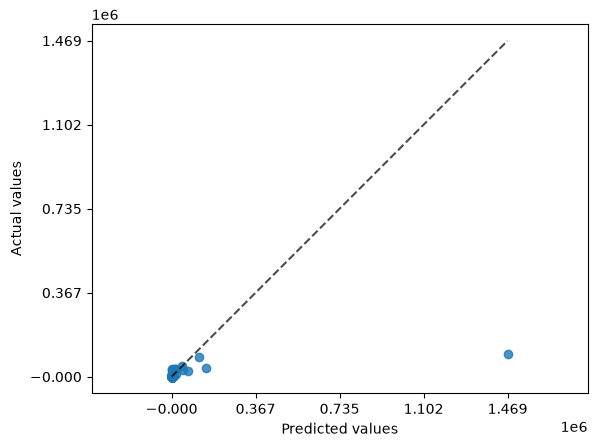

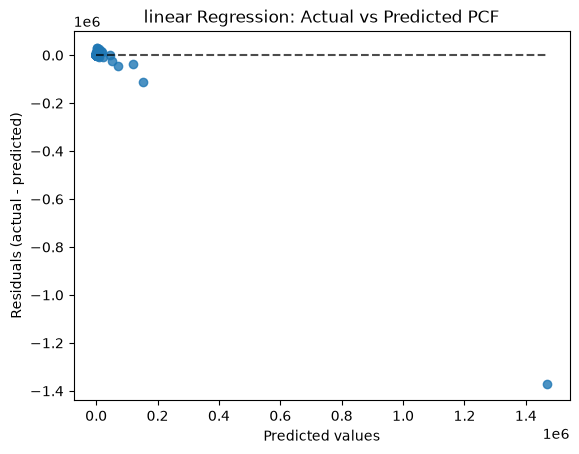

In [37]:

PredictionErrorDisplay.from_predictions(
    y_test,
    y_pred,
    kind="actual_vs_predicted"
).plot()

plt.title("linear Regression: Actual vs Predicted PCF")
plt.show()

In [38]:
print("Maximum log prediction:", y_pred_log.max())
print("Maximum original prediction:", y_pred.max())

idx = np.argmax(y_pred)

print("\nProblematic prediction:")
print("Actual:", y_test.iloc[idx])
print("Log prediction:", y_pred_log[idx])
print("Original prediction:", y_pred[idx])

Maximum log prediction: 14.200191987022038
Maximum original prediction: 1469145.2195878217

Problematic prediction:
Actual: 99075.0
Log prediction: 14.200191987022038
Original prediction: 1469145.2195878217


Linear Regression performs reasonably on the log-transformed target (R² = 0.642) but performs poorly on the original PCF scale because errors in log predictions can become very large when transformed back using expm1().

In [39]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2_original = r2_score(
    y_test,
    y_pred
)

r2_log = r2_score(
    y_test_log,
    y_pred_log
)

In [40]:
print("=" * 60)
print("Linear Regression (Baseline)")
print("=" * 60)

print(f"MAE (Original Scale)       : {mae:,.2f}")
print(f"RMSE (Original Scale)      : {rmse:,.2f}")
print(f"R² (Original Scale)        : {r2_original:.4f}")
print(f"R² (Log-transformed Scale) : {r2_log:.4f}")

Linear Regression (Baseline)
MAE (Original Scale)       : 10,777.89
RMSE (Original Scale)      : 104,438.21
R² (Original Scale)        : -70.8860
R² (Log-transformed Scale) : 0.6420


R² compares your model against simply predicting the mean of y_test.

One prediction is:

Actual       = 99,075
Predicted    = 1,469,145
Error        ≈ -1,370,070

That enormous error gets squared when calculating R² and RMSE.

That's why you have:

RMSE = 104,438
R²   = -70.886

The single extreme prediction has a very large influence.

But why is MAE only 10,777?

Because MAE doesn't square the errors. Most of your observations appear to have much smaller errors, while that one extreme prediction is dominating the squared-error metrics.

Your log R² tells a different story

You have:

R² (Log scale) = 0.642

That's actually reasonably meaningful. It means the Linear Regression model explains about 64.2% of the variance in the log-transformed PCF target.

The problem occurs when you convert:

y_pred_log

back to:

y_pred = np.expm1(y_pred_log)

because the exponential transformation magnifies large log-scale predictions.

So your interpretation should be:

Linear Regression achieved an R² of 0.642 on the log-transformed target but a negative R² of −70.886 on the original scale. The negative original-scale R² is largely driven by extreme prediction errors after transforming the predictions back from the logarithmic scale, including a prediction of approximately 1.47 million for an actual PCF of 99,075.

In [41]:
results.loc[len(results)] = [
    "Linear Regression",
    mae,
    rmse,
    r2_original,
    r2_log
]

results

,Model,MAE,RMSE,R2_Original,R2_Log
0,Linear Regression,10777.889157,104438.206531,-70.886024,0.642036


Yes — **now your calculations are on the correct scales**. However, the model's **original-scale performance is still poor**, while its log-scale performance is reasonable.

Your results:

| Metric      |       Result | Interpretation  |
| ----------- | -----------: | --------------- |
| MAE         |    10,777.89 | High            |
| RMSE        |   104,438.21 | Very high       |
| R² Original | **-70.8860** | Very poor       |
| R² Log      |   **0.6420** | Reasonably good |

### The important part

Your `R² Log = 0.6420` means the Linear Regression explains about **64.2% of the variance in the log-transformed PCF target**.

But:

```text
R² Original = -70.886
```

means that when you convert predictions back to the original PCF scale, the model performs very poorly.

This is **possible and not necessarily a coding error**, especially because your PCF target is extremely right-skewed:

```text
Skewness = 17.63
```

You have some very large PCF values, so a few bad predictions can make the original-scale RMSE and R² extremely poor.

### Your next step

Since you are comparing models, I would **keep both metrics**:

```text
R² (Log-transformed Scale)
R² (Original Scale)
MAE (Original Scale)
RMSE (Original Scale)
```

Then compare Linear Regression with Ridge, XGBoost, CatBoost, etc.

Based on the results you showed earlier, **XGBoost is performing much better than Linear Regression** on both scales.

For example, your earlier XGBoost result was approximately:

```text
XGBoost:
MAE Original       = 1,924.84
RMSE Original      = 8,445.93
R² Original        = 0.5299
R² Log             = 0.9392
```

compared with Linear Regression:

```text
Linear Regression:
MAE Original       = 10,777.89
RMSE Original      = 104,438.21
R² Original        = -70.8860
R² Log             = 0.6420
```

So **the Linear Regression result is now technically valid, but it is a weak model for your dataset**.

One thing I would check before moving on is **why the Linear Regression's original-scale predictions are so extreme**. A residual/predicted-vs-actual plot would help diagnose that.


Just be transparent in your methodology that scaling was performed after the train/test split and before cross-validation.

Your test set remains completely untouched.

Ridge Regression

ridge = Ridge(
    alpha=1.0,
    random_state=42
)

In [42]:
from sklearn.linear_model import Ridge

ridge = Ridge(
    alpha=1.0,
    random_state=42
)

In [43]:
ridge.fit(
    X_train_scaled,
    y_train_log
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary <random_state>` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",42
,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"pos

In [44]:
y_pred_log = ridge.predict(
    X_test_scaled
)

y_pred = np.expm1(
    y_pred_log
)

In [45]:
score = ridge.score(X_test, y_test_log)
score

-428157.6246931897

In [46]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2_original = r2_score(
    y_test,
    y_pred
)

r2_log = r2_score(
    y_test_log,
    y_pred_log
)

In [47]:
print("=" * 60)
print("Ridge Regression")
print("=" * 60)

print(f"MAE (Original Scale)       : {mae:,.2f}")
print(f"RMSE (Original Scale)      : {rmse:,.2f}")
print(f"R² (Original Scale)        : {r2_original:.4f}")
print(f"R² (Log-transformed Scale) : {r2_log:.4f}")

Ridge Regression
MAE (Original Scale)       : 10,378.10
RMSE (Original Scale)      : 94,236.54
R² (Original Scale)        : -57.5281
R² (Log-transformed Scale) : 0.6493


In [48]:
results.loc[len(results)] = [
    "Ridge Regression",
    mae,
    rmse,
    r2_original,
    r2_log
]

results

,Model,MAE,RMSE,R2_Original,R2_Log
0,Linear Regression,10777.889157,104438.206531,-70.886024,0.642036
1,Ridge Regression,10378.101724,94236.544159,-57.528090,0.649315


In [49]:
# Grid Search for Ridge Regression
param_grid = {
    "alpha": [0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(
    Ridge(),
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train_log)

print("Best Parameters:", grid.best_params_)
print("Best CV Score :", grid.best_score_)

Best Parameters: {'alpha': 1}
Best CV Score : 0.6928811744406481


In [50]:
best_ridge = grid.best_estimator_

In [51]:
y_pred_log = best_ridge.predict(X_test_scaled)

y_pred = np.expm1(y_pred_log)

In [52]:
score = best_ridge.score(X_test, y_test_log)
score

-428157.6246931897

In [53]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2_original = r2_score(y_test, y_pred)

r2_log = r2_score(y_test_log, y_pred_log)

In [54]:
print("=" * 60)
print("Ridge Regression")
print("=" * 60)

print(f"MAE (Original Scale)       : {mae:,.2f}")
print(f"RMSE (Original Scale)      : {rmse:,.2f}")
print(f"R² (Original Scale)        : {r2_original:.4f}")
print(f"R² (Log-transformed Scale) : {r2_log:.4f}")

Ridge Regression
MAE (Original Scale)       : 10,378.10
RMSE (Original Scale)      : 94,236.54
R² (Original Scale)        : -57.5281
R² (Log-transformed Scale) : 0.6493


In [55]:
results.loc[len(results)] = [
    "Ridge Regression (Tuned)",
    mae,
    rmse,
    r2_original,
    r2_log
]
results

,Model,MAE,RMSE,R2_Original,R2_Log
0,Linear Regression,10777.889157,104438.206531,-70.886024,0.642036
1,Ridge Regression,10378.101724,94236.544159,-57.528090,0.649315
2,Ridge Regression (Tuned),10378.101724,94236.544159,-57.528090,0.649315


Model to be work with: Support Vector Regression (SVR)

K-Nearest Neighbors (KNN)

Version 2 – Unscaled Dataset
Use this version for tree-based models, including:

Random Forest

XGBoost

LightGBM

CatBoost

Random Forest

In [56]:
from sklearn.ensemble import RandomForestRegressor



In [57]:
rf = RandomForestRegressor(
    random_state=42
)

In [58]:
rf.fit(
    X_train,
    y_train_log
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [59]:
y_pred_log = rf.predict(
    X_test
)

In [60]:
y_pred = np.expm1(
    y_pred_log
)
y_pred

array([1.32993917e+03, 4.77598377e+02, 4.10633931e+02, 9.34949762e+02,
       1.59107274e+01, 4.76825018e+01, 1.16447322e+01, 8.04035695e+02,
       1.28328405e+03, 2.00866852e+03, 2.16817749e+02, 7.94266241e+02,
       3.46565385e-01, 3.28820713e+04, 6.14609065e+02, 1.34707382e+03,
       3.06041722e+03, 7.80437679e+01, 6.10378783e-01, 3.05515922e+01,
       2.71703466e-01, 4.64928333e+03, 4.05014153e+00, 2.95566762e+04,
       2.62422360e+02, 2.26739293e+01, 7.28923389e+01, 7.24381724e+02,
       1.15501382e+02, 3.46565385e-01, 2.73839212e+01, 6.34063718e+02,
       4.77807040e-01, 6.05531900e+04, 5.63755672e+01, 1.63061481e+01,
       9.34949762e+02, 7.94266241e+02, 5.54052512e+02, 2.14349760e+03,
       8.35131710e-02, 1.64242394e+00, 6.69678766e-01, 1.39233447e+02,
       2.26709374e-02, 1.64242394e+00, 1.88484007e+03, 3.02409261e+01,
       2.32470935e+03, 3.19307017e+01, 8.23476341e+01, 1.51538940e+01,
       1.62732469e+01, 7.00300949e+01, 9.93340094e+01, 1.50385061e+01,
      

In [61]:
score = rf.score(X_test, y_test)
score

-0.10398036392780408

In [62]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2_original = r2_score(y_test, y_pred)

r2_log = r2_score(y_test_log, y_pred_log)

In [63]:
print("=" * 60)
print("Ridge Regression")
print("=" * 60)

print(f"MAE (Original Scale)       : {mae:,.2f}")
print(f"RMSE (Original Scale)      : {rmse:,.2f}")
print(f"R² (Original Scale)        : {r2_original:.4f}")
print(f"R² (Log-transformed Scale) : {r2_log:.4f}")

Ridge Regression
MAE (Original Scale)       : 1,881.31
RMSE (Original Scale)      : 8,220.72
R² (Original Scale)        : 0.5546
R² (Log-transformed Scale) : 0.9412


In [64]:
results.loc[len(results)] = [
    "Ridge Regression (Tuned)",
    mae,
    rmse,
    r2_original,
    r2_log
]
results

,Model,MAE,RMSE,R2_Original,R2_Log
0,Linear Regression,10777.889157,104438.206531,-70.886024,0.642036
1,Ridge Regression,10378.101724,94236.544159,-57.528090,0.649315
2,Ridge Regression (Tuned),10378.101724,94236.544159,-57.528090,0.649315
3,Ridge Regression (Tuned),1881.311502,8220.716770,0.554605,0.941231


In [ ]:
#GridSearch CV for Random Forest

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20,None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4,6]
}

grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(
    X_train,
    y_train_log
)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

In [ ]:
best_rf = grid.best_estimator_

y_pred_log = best_rf.predict(X_test)

y_pred = np.expm1(y_pred_log)

In [ ]:
score = best_rf.score(X_test, y_test_log)

print(score)

0.9402097600823668


In [ ]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2_original = r2_score(y_test, y_pred)

r2_log = r2_score(y_test_log, y_pred_log)

In [ ]:
print("=" * 60)
print("Ridge Regression")
print("=" * 60)

print(f"MAE (Original Scale)       : {mae:,.2f}")
print(f"RMSE (Original Scale)      : {rmse:,.2f}")
print(f"R² (Original Scale)        : {r2_original:.4f}")
print(f"R² (Log-transformed Scale) : {r2_log:.4f}")

In [ ]:
results.loc[len(results)] = [
    "Ridge Regression (Tuned)",
    mae,
    rmse,
    r2_original,
    r2_log
]
results

In [ ]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                                              Feature  Importance
3                                      Product_Weight    0.726998
1                                             Company    0.181610
5                                  Industry_Beverages    0.015144
0                                                Year    0.008187
8                    Industry_Computers & Peripherals    0.007907
7             Industry_Commercial Services & Supplies    0.007319
22                                   PCF_Protocol_ISO    0.006309
28                                      Region_Europe    0.004725
26                             PCF_Protocol_TRACI 2.1    0.004651
27                                   Region_East Asia    0.004385
18                                     Industry_Other    0.003340
23                          PCF_Protocol_Not reported    0.003105
29                               Region_North America    0.003028
6                                  Industry_Chemicals    0.002825
11  Indust

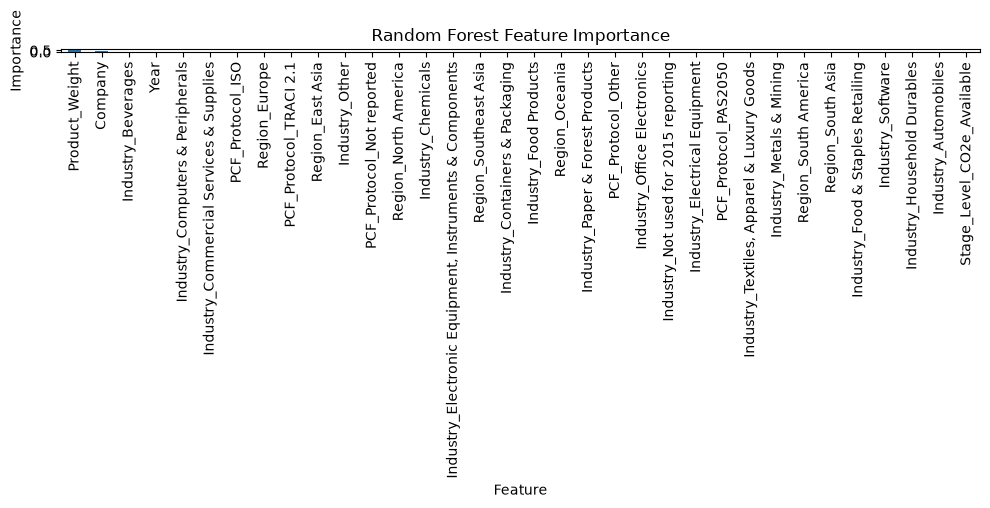

In [ ]:
import matplotlib.pyplot as plt

importance.plot(
    x="Feature",
    y="Importance",
    kind="bar",
    figsize=(10,5),
    legend=False
)

plt.title("Random Forest Feature Importance")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

In [ ]:
# Randomized Search for Random Forest

param_dist = {
    "n_estimators": [100, 200, 300, 400, 500],
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=30,    # Test 30 random combinations
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train_log)

print("Best Parameters:", random_search.best_params_)
print("Best CV Score:", random_search.best_score_)

Best Parameters: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20}
Best CV Score: 0.9150919040594838


In [ ]:
best_rf = random_search . best_estimator_

y_pred_log = best_rf.predict(X_test)

y_pred = np.expm1(y_pred_log)

In [ ]:
score = best_rf.score(X_test, y_test_log)

print(f"score:{score}")

score:0.8814803887794622


In [ ]:


mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2_original = r2_score(y_test, y_pred)

r2_log = r2_score(y_test_log, y_pred_log)

Test R² (Original Scale): 0.5196
Test R² (Log Scale): 0.8815
Variance Explained: 51.95613315960021 %


In [ ]:
print("=" * 60)
print("Ridge Regression")
print("=" * 60)

print(f"MAE (Original Scale)       : {mae:,.2f}")
print(f"RMSE (Original Scale)      : {rmse:,.2f}")
print(f"R² (Original Scale)        : {r2_original:.4f}")
print(f"R² (Log-transformed Scale) : {r2_log:.4f}")

In [ ]:
results.loc[len(results)] = [
    "Ridge Regression (Tuned)",
    mae,
    rmse,
    r2_original,
    r2_log
]
results

# XG Boost


In [ ]:
from sklearn.model_selection import xgboost
from xgboost import XGBRegressor



ModuleNotFoundError: No module named 'xgboost'

In [ ]:
xgb = XGBRegressor(
    random_state=42,
    objective="reg:squarederror"
)

In [ ]:
xgb.fit(
    X_train,
    y_train_log
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred_log = xgb.predict(X_test)

y_pred = np.expm1(y_pred_log)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt( mean_squared_error(y_test, y_pred))

r2_original = r2_score( y_test, y_pred)

r2_log = r2_score(y_test_log,y_pred_log)

In [ ]:
print("=" * 60)
print("XGBoost (Baseline)")
print("=" * 60)

print(f"MAE (Original Scale)       : {mae:.2f}")
print(f"RMSE (Original Scale)      : {rmse:.2f}")
print(f"R² (Original Scale)        : {r2_original:.4f}")
print(f"R² (Log-transformed Scale) : {r2_log:.4f}")

XGBoost (Baseline)
MAE (Original Scale)       : 1831.68
RMSE (Original Scale)      : 8500.18
R² (Original Scale)        : 0.5238
R² (Log-transformed Scale) : 0.9331


In [ ]:
results.loc[len(results)] = [
    "XGBoost (Baseline)",
    mae,
    rmse,
    r2_original,
    r2_log
]

results

,Model,MAE,RMSE,R2_Original,R2_Log
0,Linear Regression,26910.969061,298528.547167,-586.350559,0.633542
1,Ridge Regression,25143.437665,270464.586615,-481.110366,0.642319
2,Ridge Regression (Tuned),25143.437665,270464.586615,-481.110366,0.642319
3,XGBoost (Baseline),1831.680088,8500.181774,0.523808,0.933068


In [ ]:
#randomized Search for XGBoost

param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [3, 5, 7, 10],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "min_child_weight": [1, 3, 5]
}

random_search = RandomizedSearchCV(
    estimator=XGBRegressor(
        random_state=42,
        objective="reg:squarederror"
    ),
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

random_search.fit(
    X_train,
    y_train_log
)

print("Best Parameters:", random_search.best_params_)
print("Best CV Score:", random_search.best_score_)

Best Parameters: {'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.2, 'colsample_bytree': 1.0}
Best CV Score: 0.932951849225986


In [ ]:
best_xgb = random_search.best_estimator_

y_pred_log = best_xgb.predict(X_test)

y_pred = np.expm1(y_pred_log)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2_original = r2_score(y_test, y_pred)
r2_log = r2_score(y_test_log, y_pred_log)


In [ ]:
print("=" * 60)
print("XGBoost (Baseline)")
print("=" * 60)

print(f"MAE (Original Scale)       : {mae:.2f}")
print(f"RMSE (Original Scale)      : {rmse:.2f}")
print(f"R² (Original Scale)        : {r2_original:.4f}")
print(f"R² (Log-transformed Scale) : {r2_log:.4f}")

XGBoost (Baseline)
MAE (Original Scale)       : 1928.30
RMSE (Original Scale)      : 8745.53
R² (Original Scale)        : 0.4959
R² (Log-transformed Scale) : 0.9328


In [ ]:

results.loc[len(results)] = [
    "XGBoost (Tuned)",
    mae,
    rmse,
    r2_original,
    r2_log
]

In [ ]:
#grid search for XGBoost
param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.1, 0.2],
    "max_depth": [3, 5, 7],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}
grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

grid.fit(
    X_train,
    y_train_log
)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=True, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None,...
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1.0],
                         'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200, 300],
                         'subsample': [0.8, 1.0]},
             scoring='r2', verbose=1)

In [ ]:
print("Best Parameters:")
print(grid.best_params_)

print("\nBest CV Score:")
print(grid.best_score_)

Best Parameters:
{'colsample_bytree': 1.0, 'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}

Best CV Score:
0.9346951346007645


In [ ]:
best_xgb = grid.best_estimator_
y_pred_log = best_xgb.predict(X_test)

y_pred = np.expm1(y_pred_log)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2_original = r2_score(y_test, y_pred)

r2_log = r2_score(y_test_log, y_pred_log)

In [ ]:
print("=" * 60)
print("XGBoost (Baseline)")
print("=" * 60)

print(f"MAE (Original Scale)       : {mae:.2f}")
print(f"RMSE (Original Scale)      : {rmse:.2f}")
print(f"R² (Original Scale)        : {r2_original:.4f}")
print(f"R² (Log-transformed Scale) : {r2_log:.4f}")

XGBoost (Baseline)
MAE (Original Scale)       : 1924.84
RMSE (Original Scale)      : 8445.93
R² (Original Scale)        : 0.5299
R² (Log-transformed Scale) : 0.9392


In [ ]:
results.loc[len(results)] = [
    "XGBoost (GridSearchCV)",
    mae,
    rmse,
    r2_original,
    r2_log
]

results

,Model,MAE,RMSE,R2_Original,R2_Log
0,Linear Regression,26910.969061,298528.547167,-586.350559,0.633542
1,Ridge Regression,25143.437665,270464.586615,-481.110366,0.642319
2,Ridge Regression (Tuned),25143.437665,270464.586615,-481.110366,0.642319
3,XGBoost (Baseline),1831.680088,8500.181774,0.523808,0.933068
4,XGBoost (Tuned),1928.304586,8745.529151,0.495922,0.932847
5,XGBoost (GridSearchCV),1924.840394,8445.930844,0.529867,0.939172


# CAT Boost

In [ ]:
from sklearn.model_selection import catboost
from catboost import CatBoostRegressor


In [ ]:
cat = CatBoostRegressor(
    random_seed=42,
    verbose=0
)

In [ ]:
cat.fit(
    X_train,
    y_train_log
)

CatBoostRegressor(loss_function='RMSE', random_seed=42, verbose=0)

In [ ]:
y_pred_log = cat.predict(X_test)

y_pred = np.expm1(y_pred_log)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt( mean_squared_error(y_test, y_pred))

r2_original = r2_score(y_test, y_pred)

r2_log = r2_score(y_test_log,y_pred_log)

In [ ]:
print("=" * 60)
print("CatBoost (Baseline)")
print("=" * 60)

print(f"MAE (Original Scale)       : {mae:.2f}")
print(f"RMSE (Original Scale)      : {rmse:.2f}")
print(f"R² (Original Scale)        : {r2_original:.4f}")
print(f"R² (Log-transformed Scale) : {r2_log:.4f}")

CatBoost (Baseline)
MAE (Original Scale)       : 1995.96
RMSE (Original Scale)      : 8677.62
R² (Original Scale)        : 0.5037
R² (Log-transformed Scale) : 0.9038


In [ ]:
results.loc[len(results)] = [
    "CatBoost (Baseline)",
    mae,
    rmse,
    r2_original,
    r2_log
]

results

,Model,MAE,RMSE,R2_Original,R2_Log
0,Linear Regression,26910.969061,298528.547167,-586.350559,0.633542
1,Ridge Regression,25143.437665,270464.586615,-481.110366,0.642319
2,Ridge Regression (Tuned),25143.437665,270464.586615,-481.110366,0.642319
3,XGBoost (Baseline),1831.680088,8500.181774,0.523808,0.933068
4,XGBoost (Tuned),1928.304586,8745.529151,0.495922,0.932847
5,XGBoost (GridSearchCV),1924.840394,8445.930844,0.529867,0.939172
6,CatBoost (Baseline),1995.960100,8677.622818,0.503720,0.903843


In [ ]:
# Grid Search for CatBoost

param_grid = {
    "iterations": [100, 200, 300],
    "depth": [4, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1]
}

grid = GridSearchCV(
    estimator=CatBoostRegressor(
        random_seed=42,
        verbose=0
    ),
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(
    X_train,
    y_train_log
)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Parameters: {'depth': 6, 'iterations': 300, 'learning_rate': 0.1}
Best CV Score: 0.9361456912448716


In [ ]:
best_cat = grid.best_estimator_

y_pred_log = best_cat.predict(X_test)

y_pred = np.expm1(y_pred_log)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2_original = r2_score(y_test, y_pred)

r2_log = r2_score(y_test_log, y_pred_log)

In [ ]:
print("=" * 60)
print("CatBoost (Baseline)")
print("=" * 60)

print(f"MAE (Original Scale)       : {mae:.2f}")
print(f"RMSE (Original Scale)      : {rmse:.2f}")
print(f"R² (Original Scale)        : {r2_original:.4f}")
print(f"R² (Log-transformed Scale) : {r2_log:.4f}")

CatBoost (Baseline)
MAE (Original Scale)       : 2046.13
RMSE (Original Scale)      : 8730.34
R² (Original Scale)        : 0.4977
R² (Log-transformed Scale) : 0.8931


In [ ]:
results.loc[len(results)] = [
    "CatBoost (GridSearchCV)",
    mae,
    rmse,
    r2_original,
    r2_log
]

results

In [ ]:
#Randomized Search for CatBoost

param_dist = {
    "iterations": [100, 200, 300, 500],
    "depth": [4, 6, 8, 10],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "l2_leaf_reg": [1, 3, 5, 7, 9],
    "subsample": [0.8, 1.0]
}

random_search = RandomizedSearchCV(
    estimator=cat,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(
    X_train,
    y_train_log
)

In [ ]:
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest CV Score:")
print(random_search.best_score_)

In [ ]:
best_cat = random_search.best_estimator_

In [ ]:
y_pred_log = best_cat.predict(X_test)

y_pred = np.expm1(y_pred_log)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2_original = r2_score(y_test, y_pred)

r2_log = r2_score(y_test_log, y_pred_log)

In [ ]:
print("=" * 60)
print("CatBoost (RandomizedSearchCV)")
print("=" * 60)

print(f"MAE (Original Scale)       : {mae:.2f}")
print(f"RMSE (Original Scale)      : {rmse:.2f}")
print(f"R² (Original Scale)        : {r2_original:.4f}")
print(f"R² (Log-transformed Scale) : {r2_log:.4f}")

In [ ]:
results.loc[len(results)] = [
    "CatBoost (RandomizedSearchCV)",
    mae,
    rmse,
    r2_original,
    r2_log
]

results

# SVR

In [ ]:
from sklearn.svm import SVR

In [ ]:
svr = SVR()

svr.fit(X_train_scaled, y_train_log)

In [ ]:
y_pred_log = svr.predict(X_test_scaled)

y_pred = np.expm1(y_pred_log)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2_original = r2_score(y_test, y_pred)

r2_log = r2_score(y_test_log, y_pred_log)



In [ ]:
print("="*60)
print("SVR (Baseline)")
print("="*60)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Original: {r2_original:.4f}")
print(f"R² Log: {r2_log:.4f}")

In [ ]:
results.loc[len(results)] = [
    "SVR Base Linee",
    mae,
    rmse,
    r2_original,
    r2_log
]

results

In [ ]:
#GridSearch CV

param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", "auto", 0.01, 0.1],
    "kernel": ["rbf", "linear"]
}

grid = GridSearchCV(
    estimator=SVR(),
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(
    X_train_scaled,
    y_train_log
)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

In [ ]:
best_svr_grid = grid.best_estimator_

y_pred_log = best_svr_grid.predict(X_test_scaled)

y_pred = np.expm1(y_pred_log)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2_original = r2_score(y_test, y_pred)

r2_log = r2_score(y_test_log, y_pred_log)

In [ ]:
print("="*60)
print("SVR (GridSearch CV)")
print("="*60)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Original: {r2_original:.4f}")
print(f"R² Log: {r2_log:.4f}")

In [ ]:
results.loc[len(results)] = [
    "SVR (Gridsearch CV)",
    mae,
    rmse,
    r2_original,
    r2_log
]

results

In [ ]:
#RandomSearch CV

param_dist = {
    "C": [0.1, 1, 10, 50, 100, 500],
    "gamma": ["scale", "auto", 0.001, 0.01, 0.1, 1],
    "kernel": ["rbf", "linear", "poly"]
}

random_search = RandomizedSearchCV(
    estimator=SVR(),
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

random_search.fit(
    X_train_scaled,
    y_train_log
)

print("Best Parameters:", random_search.best_params_)
print("Best CV Score:", random_search.best_score_)

In [ ]:
best_svr_random = random_search.best_estimator_

y_pred_log = best_svr_random.predict(X_test_scaled)

y_pred = np.expm1(y_pred_log)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2_original = r2_score(y_test, y_pred)

r2_log = r2_score(y_test_log, y_pred_log)

In [ ]:
print("="*60)
print("SVR (Randomsearch CV)")
print("="*60)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Original: {r2_original:.4f}")
print(f"R² Log: {r2_log:.4f}")

In [ ]:
results.loc[len(results)] = [
    "SVR (Randomsearch CV)",
    mae,
    rmse,
    r2_original,
    r2_log
]

results